In [2]:
import pandas as pd
import os, json

import json, pickle
import random
import numpy as np
from statistics import mean
from scipy.stats import ttest_rel, ttest_ind
import csv
import pandas as pd
import time
from tqdm import tqdm  # for progress bar
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

## Rating score extraction (Human and CLIP)

In [3]:
"""
Extract rating scores from individual result files from deployed folder and compile them into a single CSV file.
"""
import os
from datetime import datetime
import pandas as pd

formal_dir = "/opt/jinhanz/results/2509_concreteness/deployed/deploy_0818/formal/" # TODO: setup config info file
df_human = pd.DataFrame()

excluded_participants = [ "004", "015", "011", "007", "018", "031", "025", "036", "053", "046", "026", "051", "039", "074","057"]

data_root = "/opt/jinhanz/results/2509_concreteness/results/251215_cogsci_60/"
output_dir = os.path.join(data_root, "human", "ratings")

for b in range(1,5):
    block_dir = os.path.join(formal_dir, f"Block{b}_deploy", "results")
    
    for subject_dir in os.listdir(block_dir):
        subject_path = os.path.join(block_dir, subject_dir)
        if not os.path.isdir(subject_path):
            continue

        if subject_dir[:3] in excluded_participants:
            continue
        
        subject_res_path = os.path.join(subject_path, "RESULTS_FILE.txt")

        if os.path.exists(subject_res_path):
            df = pd.read_csv(subject_res_path, sep='\s+')
            # TODO: assert subject number matches, assert block number matches
            # TODO: readin block order information
            df_human = pd.concat([df_human, df], ignore_index=True)
df_human['answer'] = df_human['answer'] / 100
df_human['image_id'] = df_human['imagename'].apply(lambda x: f"val2014/{'_'.join(x.split('_')[2:])}")
df_human['match'] = df_human['imagename'].apply(lambda x: x.split('_')[0])
df_human['condition'] = df_human['imagename'].apply(lambda x: x.split('_')[1])
# df_human.to_csv(os.path.join(output_dir, f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_rating_scores.csv"), index=False)

### Filter by EMHMM group

In [7]:
import scipy.io as sio
import numpy as np
import pandas as pd
import torch

vbcogroup_hmms = sio.loadmat(os.path.join(data_root, "emhmm", "image", "variables", "vbcogroup_hmms.mat"))

group1_subjs_idx = vbcogroup_hmms['vbco']['groups'][0,0][0,0].squeeze()
group2_subjs_idx = vbcogroup_hmms['vbco']['groups'][0,0][0,1].squeeze()

SubjNames = sio.loadmat(os.path.join(data_root, "emhmm", "image", "variables", "SubjNames.mat"))
SubjNames = SubjNames['SubjNames']

group1_subjs = SubjNames[group1_subjs_idx-1]
group2_subjs = SubjNames[group2_subjs_idx-1]

group1_subjs = np.array(group1_subjs.flatten(), dtype=int)
group2_subjs = np.array(group2_subjs.flatten(), dtype=int)

/tmp/ipykernel_3400596/649269805.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  group1_subjs = np.array(group1_subjs.flatten(), dtype=int)
/tmp/ipykernel_3400596/649269805.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  group2_subjs = np.array(group2_subjs.flatten(), dtype=int)


In [8]:
df_grp1 = df_human[df_human['subject_no'].isin(group1_subjs)]
df_grp2 = df_human[df_human['subject_no'].isin(group2_subjs)]

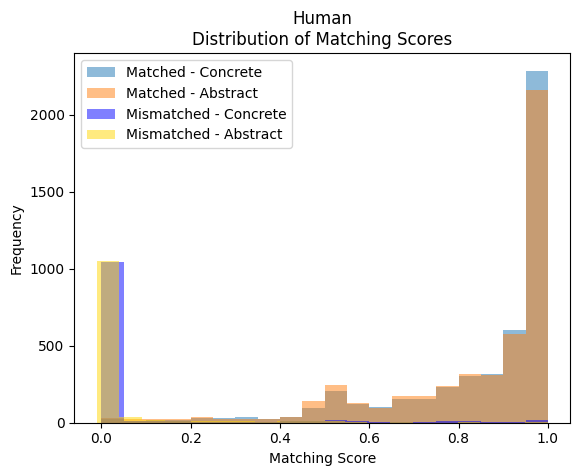

In [5]:
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.hist(df_human[(df_human['match'] == 'mismatched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='blue', alpha=0.5, label='Mismatched - Concrete')
plt.hist(df_human[(df_human['match'] == 'mismatched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='gold', alpha=0.5, label='Mismatched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.title('Human\nDistribution of Matching Scores')
plt.legend()
plt.show()

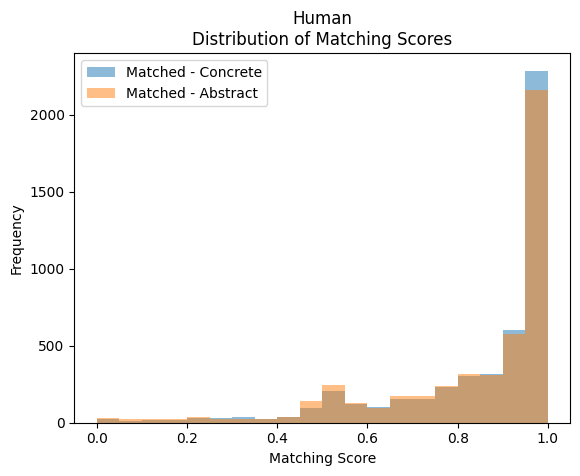

In [8]:
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.title('Human\nDistribution of Matching Scores')
plt.legend()
plt.show()

## Human Model Alignment

In [4]:
experiment = '20250723_193742'

df_clip = pd.read_csv(f"/opt/jinhanz/results/2509_concreteness/stimuli/250602-250723_stimuli_average/{experiment}/captions_and_attributes.csv")
df_clip = df_clip.sort_values(by='image_id')

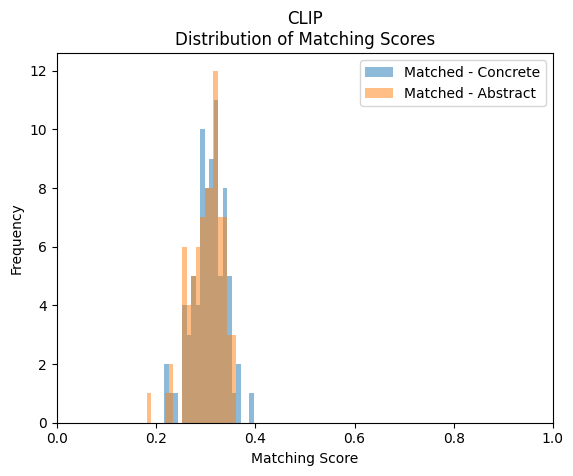

In [5]:
plt.hist(df_clip['con_matching_score'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_clip['abs_matching_score'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.xlim(0, 1)
plt.title('CLIP\nDistribution of Matching Scores')
plt.legend()
plt.show()

### Rating Normalization

In [9]:
df_human = df_human[df_human['match'] == 'matched']
df_human['answer_normalized'] = df_human.groupby('subject_no')['answer'].transform(lambda x: (x - x.mean()) / x.std())
df_grp1['answer_normalized'] = df_grp1.groupby('subject_no')['answer'].transform(lambda x: (x - x.mean()) / x.std())
df_grp2['answer_normalized'] = df_grp2.groupby('subject_no')['answer'].transform(lambda x: (x - x.mean()) / x.std())

In [10]:
all_values = pd.concat(
    [df_clip['abs_matching_score'], df_clip['con_matching_score']],
    ignore_index=True
)

mean = all_values.mean()
std = all_values.std()

df_clip['abs_matching_score_normalized'] = (df_clip['abs_matching_score'] - mean) / std
df_clip['con_matching_score_normalized'] = (df_clip['con_matching_score'] - mean) / std

### By-subject

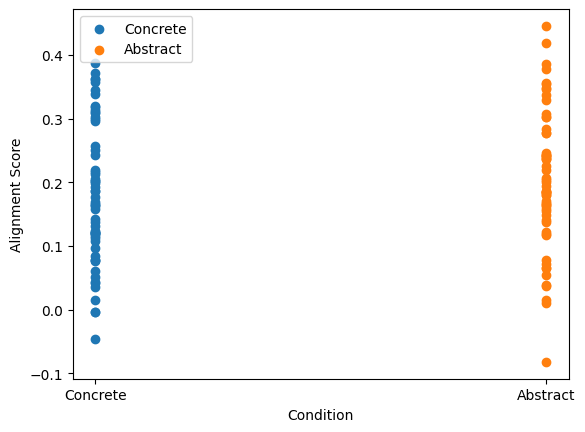

In [122]:
plt.scatter([0]*len(alignment_con), alignment_con, color='tab:blue', label='Concrete')
plt.scatter([1]*len(alignment_abs), alignment_abs, color='tab:orange', label='Abstract')
plt.xlabel('Condition')
plt.ylabel('Alignment Score')
plt.xticks([0, 1], ['Concrete', 'Abstract'])
plt.legend()
plt.show()

In [ ]:
subjs = df_human['subject_no'].unique()
subj_num = len(subjs)

alignment_con = np.zeros(subj_num)
alignment_abs = np.zeros(subj_num)
long_format_data = pd.DataFrame()

for s, subj in enumerate(subjs):
    df_subj = df_human[(df_human['match'] == 'matched') & (df_human['subject_no']==subj)]
    df_subj_con = df_subj[df_subj['condition'] == 'con'].sort_values(by='image_id')
    df_subj_abs = df_subj[df_subj['condition'] == 'abs'].sort_values(by='image_id')

    assert df_subj_con['image_id'].tolist() == df_clip['image_id'].tolist()
    assert df_subj_abs['image_id'].tolist() == df_clip['image_id'].tolist()

    alignment_con[s] = np.corrcoef(pd.to_numeric(df_subj_con['answer_normalized']), df_clip["con_matching_score_normalized"])[0,1]
    alignment_abs[s] = np.corrcoef(pd.to_numeric(df_subj_abs['answer_normalized']), df_clip["abs_matching_score_normalized"])[0,1]

    long_format_data = pd.concat([
        long_format_data,
        pd.DataFrame([{
            "subject": s,
            "condition": 'con',
            "group": "1" if subj in group1_subjs else "2",
            "alignment": alignment_con[s],
        },{
            "subject": s,
            "condition": 'abs',
            "group": "1" if subj in group1_subjs else "2",
            "alignment": alignment_abs[s],
        }])
    ], ignore_index=True)

long_format_data.to_csv("./data_rating/lmm_pcc_by_subject.csv", index=False)

model = smf.mixedlm(f"alignment ~ condition", long_format_data, groups="subject")
result = model.fit()
print(result.summary())

model = smf.mixedlm(f"alignment ~ group * condition", long_format_data, groups="subject")
result = model.fit()
print(result.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  alignment
No. Observations:   120      Method:              REML     
No. Groups:         60       Scale:               0.0062   
Min. group size:    2        Log-Likelihood:      97.6909  
Max. group size:    2        Converged:           Yes      
Mean group size:    2.0                                    
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.203    0.014 14.436 0.000  0.176  0.231
condition[T.con] -0.023    0.014 -1.579 0.114 -0.051  0.005
subject Var       0.006    0.029                           

                Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      alignment
No. Observations:      120          Method:                  REML     
No. Groups:            60         

/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


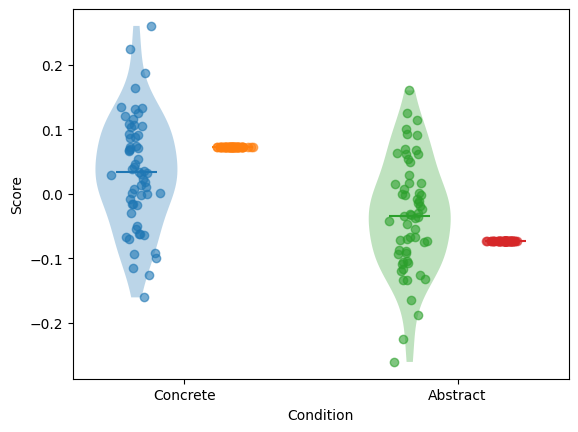

In [ ]:
from scipy.stats import pearsonr
from statsmodels.stats.anova import AnovaRM
import pandas as pd

# Prepare the data for ANOVA
# 'Condition' (Concrete vs Abstract) is a within-subject factor, not a between-subject factor.
subjs = df_human['subject_no'].unique()
subj_num = len(subjs)

score_human_con = np.zeros(subj_num)
score_human_abs = np.zeros(subj_num)
score_clip_con = np.zeros(subj_num)
score_clip_abs = np.zeros(subj_num)

for s, subj in enumerate(subjs):
    df_subj_human = df_human[(df_human['match'] == 'matched') & (df_human['subject_no']==subj)]
    score_human_con[s] = df_subj_human[df_subj_human['condition'] == 'con']['answer_normalized'].mean()
    score_human_abs[s] = df_subj_human[df_subj_human['condition'] == 'abs']['answer_normalized'].mean()

    score_clip_con[s] = df_clip['con_matching_score_normalized'].mean()
    score_clip_abs[s] = df_clip['abs_matching_score_normalized'].mean()

data = pd.DataFrame({
    'Subject': np.concatenate([subjs, subjs]),
    'Condition': ['Concrete'] * subj_num + ['Abstract'] * subj_num,
    'Human': np.concatenate([score_human_con, score_human_abs]),
    'CLIP': np.concatenate([score_clip_con, score_clip_abs])
})

data.to_csv("./data_rating/anova_by_subject_normalized.csv")

# Melt the data for repeated measures ANOVA
data_melted = pd.melt(data, id_vars=['Subject', 'Condition'], value_vars=['Human', 'CLIP'], 
                      var_name='Model', value_name='Score')

import numpy as np
import matplotlib.pyplot as plt

conditions = ["Concrete", "Abstract"]
models = ["Human", "CLIP"]

fig, ax = plt.subplots()

width = 0.35
positions = {
    ("Concrete", "Human"): 0 - width/2,
    ("Concrete", "CLIP"): 0 + width/2,
    ("Abstract", "Human"): 1 - width/2,
    ("Abstract", "CLIP"): 1 + width/2,
}

# draw violins
for cond in conditions:
    for model in models:
        subset = data_melted[
            (data_melted["Condition"] == cond) &
            (data_melted["Model"] == model)
        ]["Score"].values
        
        pos = positions[(cond, model)]
        
        parts = ax.violinplot(
            subset,
            positions=[pos],
            widths=0.3,
            showmeans=True,
            showextrema=False
        )
        
# overlay individual points (jittered)
for cond in conditions:
    for model in models:
        subset = data_melted[
            (data_melted["Condition"] == cond) &
            (data_melted["Model"] == model)
        ]
        
        pos = positions[(cond, model)]
        
        jitter = np.random.normal(0, 0.03, size=len(subset))
        
        ax.scatter(
            np.full(len(subset), pos) + jitter,
            subset["Score"],
            alpha=0.6
        )

ax.set_xticks([0, 1])
ax.set_xticklabels(conditions)
ax.set_xlabel("Condition")
ax.set_ylabel("Score")

plt.show()

# anova_results_rm = AnovaRM(data_melted, 'Score', 'Image', 
#                            within=['Model'], 
#                            between=['Condition']).fit()

# print(anova_results_rm)

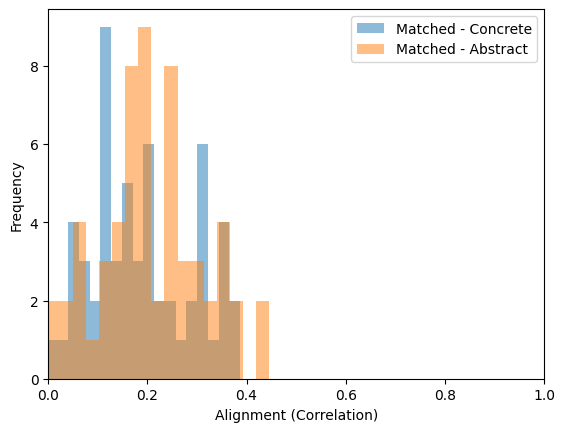

In [14]:
plt.hist(alignment_con, bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(alignment_abs, bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.xlabel('Alignment (Correlation)')
plt.ylabel('Frequency')
plt.xlim(0, 1)
# plt.title('CLIP\nDistribution of Matching Scores')
plt.legend()
plt.show()

In [15]:
t_stat, p_value = ttest_rel(alignment_con, alignment_abs)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -1.5794473166285674, P-value: 0.11958036444948811


### By item

In [13]:
imgs = df_clip['image_id'].unique()
img_num = len(imgs)

score_human_con = np.zeros(img_num)
score_human_abs = np.zeros(img_num)
score_group1_con = np.zeros(img_num)
score_group1_abs = np.zeros(img_num)
score_group2_con = np.zeros(img_num)
score_group2_abs = np.zeros(img_num)

score_clip_con = np.zeros(img_num)
score_clip_abs = np.zeros(img_num)

for i, img in enumerate(imgs):
    df_img_human = df_human[(df_human['match'] == 'matched') & (df_human['image_id']==img)]
    score_human_con[i] = df_img_human[df_img_human['condition'] == 'con']['answer_normalized'].mean()
    score_human_abs[i] = df_img_human[df_img_human['condition'] == 'abs']['answer_normalized'].mean()

    df_img_grp1 = df_grp1[(df_grp1['match'] == 'matched') & (df_grp1['image_id']==img)]
    score_group1_con[i] = df_img_grp1[df_img_grp1['condition']=='con']['answer_normalized'].mean()
    score_group1_abs[i] = df_img_grp1[df_img_grp1['condition']=='abs']['answer_normalized'].mean()
    
    df_img_grp2 = df_grp2[(df_grp2['match'] == 'matched') & (df_grp2['image_id']==img)]
    score_group2_con[i] = df_img_grp2[df_img_grp2['condition']=='con']['answer_normalized'].mean()
    score_group2_abs[i] = df_img_grp2[df_img_grp2['condition']=='abs']['answer_normalized'].mean()

    score_clip_con[i] = df_clip[df_clip['image_id'] == img]['con_matching_score_normalized'].values[0]
    score_clip_abs[i] = df_clip[df_clip['image_id'] == img]['abs_matching_score_normalized'].values[0]

In [ ]:
from scipy.stats import pearsonr
from statsmodels.stats.anova import AnovaRM
import pandas as pd

# Prepare the data for ANOVA
# 'Condition' (Concrete vs Abstract) is a within-subject factor, not a between-subject factor.
data = pd.DataFrame({
    'Image': list(range(1, img_num + 1)) * 2,
    'Condition': ['Concrete'] * img_num + ['Abstract'] * img_num,
    'Human': np.concatenate([score_human_con, score_human_abs]),
    'CLIP': np.concatenate([score_clip_con, score_clip_abs])
})

data.to_csv("./data_rating/anova_by_item.csv")

# Melt the data for repeated measures ANOVA
data_melted = pd.melt(data, id_vars=['Image', 'Condition'], value_vars=['Human', 'CLIP'], 
                      var_name='Model', value_name='Score')

# anova_results_rm = AnovaRM(data_melted, 'Score', 'Image', 
#                            within=['Model'], 
#                            between=['Condition']).fit()

# print(anova_results_rm)

/tmp/ipykernel_3298530/719454953.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


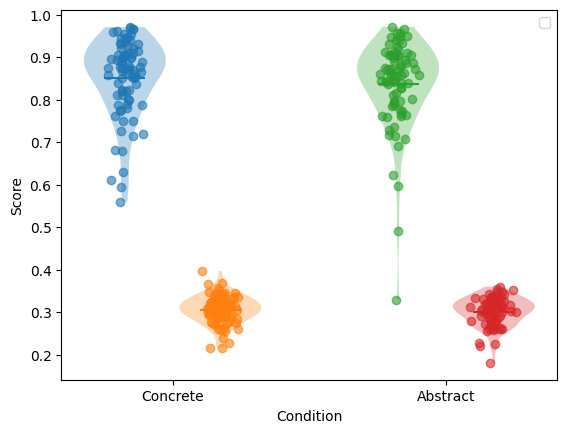

In [125]:
# Melt the data for repeated measures ANOVA
data_melted = pd.melt(data, id_vars=['Image', 'Condition'], value_vars=['Human', 'CLIP'], 
                      var_name='Model', value_name='Score')

import numpy as np
import matplotlib.pyplot as plt

conditions = ["Concrete", "Abstract"]
models = ["Human", "CLIP"]

fig, ax = plt.subplots()

width = 0.35
positions = {
    ("Concrete", "Human"): 0 - width/2,
    ("Concrete", "CLIP"): 0 + width/2,
    ("Abstract", "Human"): 1 - width/2,
    ("Abstract", "CLIP"): 1 + width/2,
}

# draw violins
for cond in conditions:
    for model in models:
        subset = data_melted[
            (data_melted["Condition"] == cond) &
            (data_melted["Model"] == model)
        ]["Score"].values
        
        pos = positions[(cond, model)]
        
        parts = ax.violinplot(
            subset,
            positions=[pos],
            widths=0.3,
            showmeans=True,
            showextrema=False
        )
        
# overlay individual points (jittered)
for cond in conditions:
    for model in models:
        subset = data_melted[
            (data_melted["Condition"] == cond) &
            (data_melted["Model"] == model)
        ]
        
        pos = positions[(cond, model)]
        
        jitter = np.random.normal(0, 0.03, size=len(subset))
        
        ax.scatter(
            np.full(len(subset), pos) + jitter,
            subset["Score"],
            alpha=0.6
        )

ax.set_xticks([0, 1])
ax.set_xticklabels(conditions)
ax.set_xlabel("Condition")
ax.set_ylabel("Score")

plt.legend()
plt.show()


maybe also test human accuracy on matched vs mismatched?

Mixed effect model

In [ ]:
long_format_data = pd.DataFrame()
for i, img in enumerate(imgs):
        for condition in ["con","abs"]:
            long_format_data = pd.concat([
                long_format_data,
                pd.DataFrame([{
                    "image": i,
                    "condition": condition,
                    "model": "human",
                    "rating": score_human_con[i] if condition=="con" else score_human_abs[i]
                },{
                    "image": i,
                    "condition": condition,
                    "model": "clip",
                    "rating": score_clip_con[i] if condition=="con" else score_clip_abs[i]
                }])
            ], ignore_index=True)

long_format_data.head()
long_format_data.to_csv("./data_rating/lmm_by_item.csv", index=False)

In [45]:
score_human_con.min(), score_human_con.max(), score_human_abs.min(), score_human_abs.max()
score_clip_con.min(), score_clip_con.max(), score_clip_abs.min(), score_clip_abs.max()

(-2.607336543187284,
 2.784902575786531,
 -3.6806732398550577,
 1.6896610485745172)

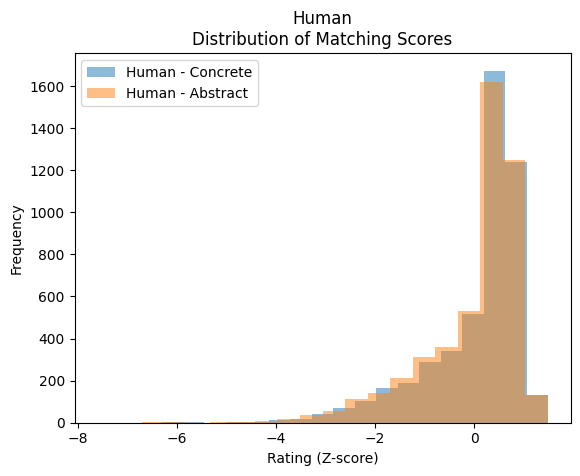

In [54]:
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'con')]['answer_normalized'], bins=20, alpha=0.5, label='Human - Concrete')
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'abs')]['answer_normalized'], bins=20, alpha=0.5, label='Human - Abstract')
# plt.hist(df_clip['con_matching_score_normalized'], bins=20, alpha=0.5, label='Clip - Concrete')
# plt.hist(df_clip['abs_matching_score_normalized'], bins=20, alpha=0.5, label='Clip - Abstract')


plt.xlabel('Rating (Z-score)')
plt.ylabel('Frequency')
plt.title('Human\nDistribution of Matching Scores')
plt.legend()
plt.show()

In [13]:
import statsmodels.formula.api as smf

print(f"Mixed-Effect Model Analysis for rating:")
# long_format_data['model'] = long_format_data['model'].astype('category')
# long_format_data['model'] = long_format_data['model'].cat.reorder_categories(['human', 'clip'], ordered=False)
model = smf.mixedlm(f"rating ~ condition * model", long_format_data, groups="image")
result = model.fit()
print(result.summary())

Mixed-Effect Model Analysis for rating:
                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       rating  
No. Observations:        320           Method:                   REML    
No. Groups:              80            Scale:                    0.0046  
Min. group size:         4             Log-Likelihood:           373.4376
Max. group size:         4             Converged:                Yes     
Mean group size:         4.0                                             
-------------------------------------------------------------------------
                                Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                       0.302    0.008 36.922 0.000  0.286  0.318
condition[T.con]                0.005    0.011  0.454 0.650 -0.016  0.026
model[T.human]                  0.536    0.011 49.970 0.000  0.515  0.557
condition[T.con]

/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


##### Mixed effect model with EMHMM

In [21]:
long_format_data = pd.DataFrame()
for i, img in enumerate(imgs):
        for condition in ["con","abs"]:
            long_format_data = pd.concat([
                long_format_data,
                pd.DataFrame([{
                    "image": i,
                    "condition": condition,
                    "model": "grp1",
                    "rating": score_group1_con[i] if condition=="con" else score_group1_abs[i]
                },
                {
                    "image": i,
                    "condition": condition,
                    "model": "grp2",
                    "rating": score_group2_con[i] if condition=="con" else score_group2_abs[i]
                },
                # {
                #     "image": i,
                #     "condition": condition,
                #     "model": "clip",
                #     "rating": score_clip_con[i] if condition=="con" else score_clip_abs[i]
                # }
                ])
            ], ignore_index=True)

print(f"Mixed-Effect Model Analysis for rating:")
long_format_data['model'] = long_format_data['model'].astype('category')
# long_format_data['model'] = long_format_data['model'].cat.reorder_categories(['grp1', 'grp2', 'clip'], ordered=False)
model = smf.mixedlm(f"rating ~ condition * model", long_format_data, groups="image")
result = model.fit()
print(result.summary())

Mixed-Effect Model Analysis for rating:
                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       rating  
No. Observations:        320           Method:                   REML    
No. Groups:              80            Scale:                    0.0536  
Min. group size:         4             Log-Likelihood:           -35.8095
Max. group size:         4             Converged:                Yes     
Mean group size:         4.0                                             
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                       0.416    0.031 13.300 0.000  0.354  0.477
condition[T.con]                0.035    0.037  0.965 0.335 -0.036  0.107
model[T.grp2]                  -0.037    0.037 -1.003 0.316 -0.108  0.035
condition[T.con]

### Human - CLIP (Subject and Item modeled together)

In [23]:
subjs

array([24, 21, 60, 48, 23, 77, 6, 76, 38, 70, 16, 22, 69, 12, 45, 59, 61,
       50, 34, 54, 28, 58, 43, 55, 52, 75, 56, 3, 10, 9, 67, 19, 2, 37,
       62, 27, 20, 71, 40, 73, 49, 17, 14, 32, 1, 30, 13, 66, 64, 65, 68,
       35, 5, 33, 47, 41, 42, 44, 29, 8], dtype=object)

In [32]:
df_img_human.size

1200

In [ ]:
import statsmodels.formula.api as smf

long_format_data = pd.DataFrame()
for i, img in enumerate(imgs):
    for subj in subjs:
        for condition in ["con","abs"]:
            rating_human = df_human[(df_human['image_id'] == img) & (df_human['condition'] == condition) & (df_human['subject_no'] == subj)]['answer_normalized'].values[0]
            rating_clip = df_clip[df_clip['image_id'] == img][f"{condition}_matching_score_normalized"].values[0]
            long_format_data = pd.concat([
                long_format_data,
                pd.DataFrame([{
                    "image": img,
                    "condition": condition,
                    "subject": f"subj_{subj}",
                    "rating_human": rating_human,
                    "rating_clip": rating_clip,
                    "rating_diff": rating_human - rating_clip,
                    "abs_rating_diff": abs(rating_human - rating_clip),
                }])
            ], ignore_index=True)

long_format_data.head()
long_format_data.to_csv("data_rating/rating_diff_long_format.csv", index=False)

In [57]:
print(f"Mixed-Effect Model Analysis for rating:")
# long_format_data['model'] = long_format_data['model'].astype('category')
# long_format_data['model'] = long_format_data['model'].cat.reorder_categories(['human', 'clip'], ordered=False)
model = smf.mixedlm("abs_rating_diff ~ condition", 
                    long_format_data, 
                    groups="subject",)                 # primary random effect
result = model.fit()
print(result.summary())

Mixed-Effect Model Analysis for rating:
                Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    abs_rating_diff
No. Observations:    9600       Method:                REML           
No. Groups:          60         Scale:                 0.6867         
Min. group size:     160        Log-Likelihood:        inf            
Max. group size:     160        Converged:             Yes            
Mean group size:     160.0                                            
----------------------------------------------------------------------
                 Coef.   Std.Err.    z    P>|z|    [0.025     0.975]  
----------------------------------------------------------------------
Intercept        -0.037 214527.191 -0.000 1.000 -420465.605 420465.530
condition[T.con] -0.022      0.017 -1.309 0.191      -0.055      0.011
subject Var       0.000                                               



/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE m

In [67]:
t_stat, p_value = ttest_rel(long_format_data[long_format_data["condition"] == "con"]["rating_diff"], long_format_data[long_format_data["condition"] == "abs"]["rating_diff"])
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -3.204605499478155, P-value: 0.0013613331297563087


/tmp/ipykernel_3400596/616831123.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(subjects))


KeyboardInterrupt: 

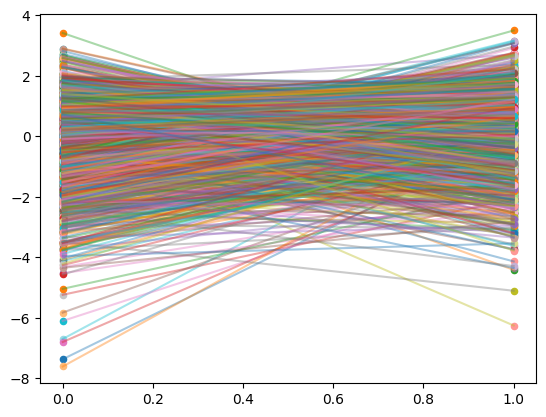

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# choose which metric to plot
y_var = "rating_diff"   # or "abs_rating_diff"

# make sure condition order is consistent
long_format_data["condition"] = pd.Categorical(
    long_format_data["condition"],
    categories=["con", "abs"],
    ordered=True
)

# unique subjects and color map
subjects = long_format_data["subject"].unique()
cmap = plt.cm.get_cmap("tab20", len(subjects))
subject_color = {subj: cmap(i) for i, subj in enumerate(subjects)}

fig, ax = plt.subplots()

# group by image
for img, img_df in long_format_data.groupby("image"):
    
    # sort by condition so con -> abs
    img_df = img_df.sort_values("condition")
    
    # there will be multiple rows (one per subject per condition)
    # so we connect within subject inside each image
    for subj, subj_df in img_df.groupby("subject"):
        subj_df = subj_df.sort_values("condition")
        
        x = subj_df["condition"].cat.codes
        y = subj_df[y_var].values
        
        ax.plot(x, y, alpha=0.4)  # connecting line
        ax.scatter(x, y, color=subject_color[subj], s=20)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Concrete", "Abstract"])
ax.set_xlabel("Condition")
ax.set_ylabel(y_var)
plt.show()

/tmp/ipykernel_3400596/3937471256.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_format_data, x='condition', y=measure,


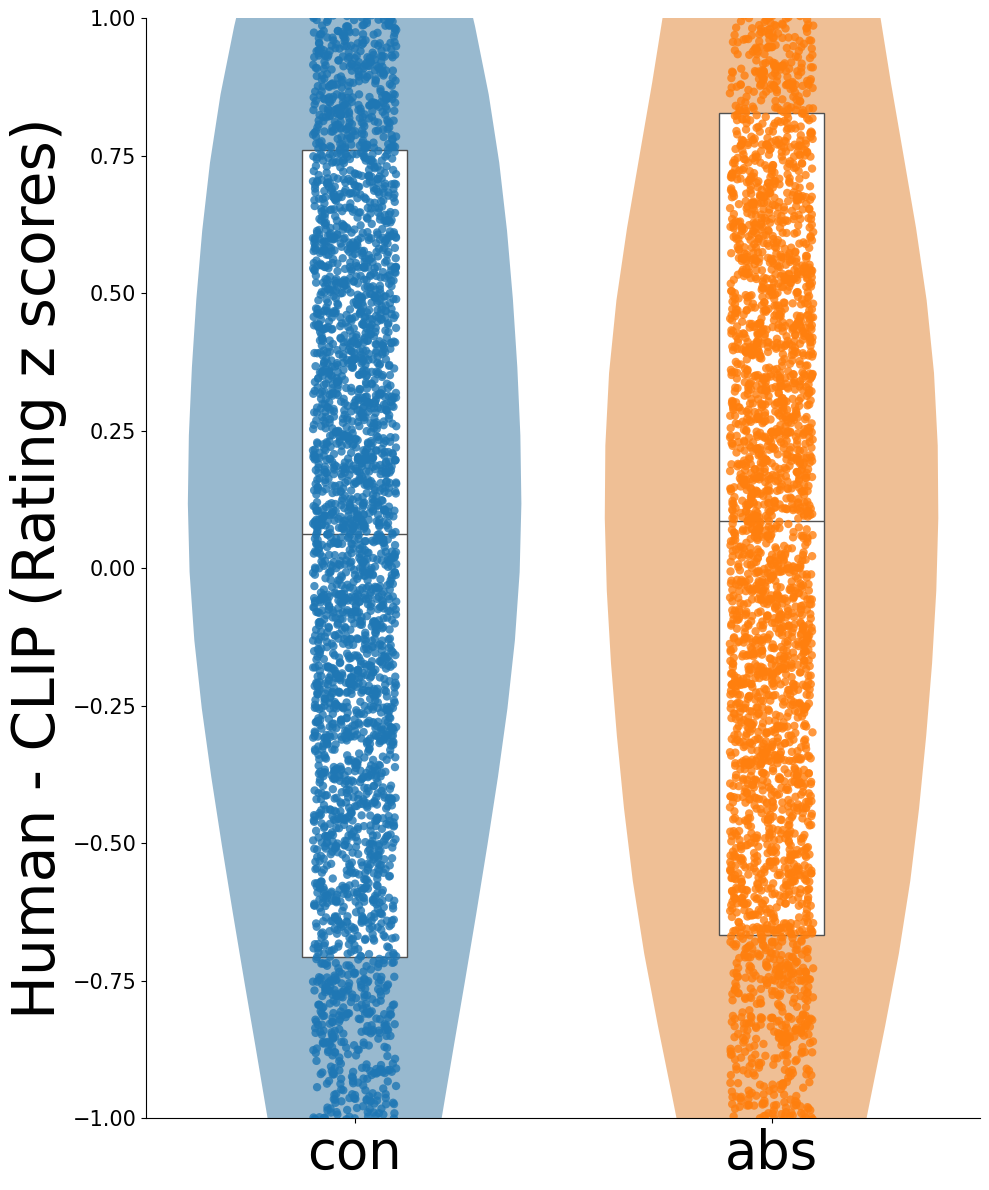

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Choose colors (you can tweak these)
palette = {"abs": "tab:orange", "con": "tab:blue"}  # blue vs orange

plt.figure(figsize=(10, 12))

measure = "rating_diff"

# Violin plot (distribution)
sns.violinplot(data=long_format_data, x='condition', y=measure,
               inner=None, linewidth=0, palette=palette, alpha=0.5)

# Boxplot overlay (median + IQR)
sns.boxplot(data=long_format_data, x='condition', y=measure, width=0.25,
            showcaps=False, boxprops={'facecolor':'white', 'zorder':3},
            showfliers=False, whiskerprops={'linewidth':0}, zorder=3)

# # Jittered individual points
sns.stripplot(data=long_format_data, x='condition', y=measure, hue='condition',
              palette=palette, dodge=False, alpha=0.8, size=6, jitter=0.1, zorder=4)

# Clean up legend (duplicate hue)
plt.legend([],[], frameon=False)

# Significance annotation
y_max = long_format_data[measure].max()
y_sig = y_max + 0.05 * (long_format_data[measure].max() - long_format_data[measure].min())

# Labels & title
# plt.title(f"Concrete > Abstract (t={t_stat:.2f}, p={p_value:.3f})", fontsize=36)
plt.xticks(fontsize=38)  # Adjust the font size as needed
plt.yticks(fontsize=15)  # Adjust the font size as needed
plt.xlabel('')
plt.ylabel("Human - CLIP (Rating z scores)", fontsize=42)
# plt.ylim(-1,1)
sns.despine()
plt.tight_layout()
plt.show()